In [1]:
print("Hi")

Hi


In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [5]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [6]:
import os
os.listdir('/content')

['.config', 'creditcard.csv', 'archive.zip', 'sample_data']

In [7]:
import pandas as pd

df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.shape

(284807, 31)

In [9]:
df.isnull().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [10]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [11]:
df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


In [12]:
df.groupby('Class')['Amount'].mean()

,Amount
Class,
0,88.291022
1,122.211321


In [13]:
# Fraudulent transactions have a higher average amount (122.21)
# than legitimate transactions (88.29).

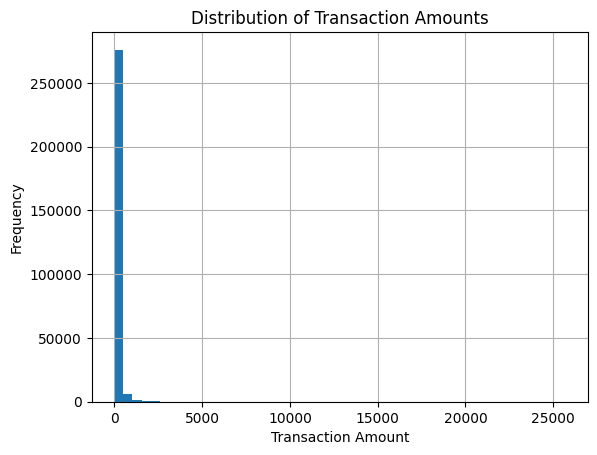

In [14]:
import matplotlib.pyplot as plt

df['Amount'].hist(bins=50)

plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amounts')
plt.show()

In [15]:
# Count of legit (0) vs fraud (1)
print(df['Class'].value_counts())

# Same thing as a percentage
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [16]:
# Summary of Amount, split by legit vs fraud
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [17]:
from scipy.stats import ttest_ind

# Split Amount into the two groups
legit_amounts = df[df['Class'] == 0]['Amount']
fraud_amounts = df[df['Class'] == 1]['Amount']

# Two-sample t-test (Welch's, safer when the groups differ in size and spread)
t_stat, p_value = ttest_ind(legit_amounts, fraud_amounts, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -2.928789530856467
p-value: 0.003560518851710299


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features (X) = every column except the answer (Class) and Time
X = df.drop(['Class', 'Time'], axis=1)
# Target (y) = the fraud label
y = df['Class']

# Hold back 30% to test on, keeping the fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Put all features on the same scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on the held-out test set
y_pred = model.predict(X_test)

# See how it did
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[85280    15]
 [   57    91]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [23]:
# Same model, but tell it to take fraud (the rare class) more seriously
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

[[83407  1888]
 [   19   129]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.87      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [24]:
# Get the model's probability of fraud for each transaction (0 to 1)
fraud_probs = model_balanced.predict_proba(X_test)[:, 1]

# Default flags anything >= 0.5. Let's try moving the cutoff and watch the tradeoff shift.
for threshold in [0.5, 0.9, 0.99]:
    custom_preds = (fraud_probs >= threshold).astype(int)
    print(f"\n----- Threshold = {threshold} -----")
    print(confusion_matrix(y_test, custom_preds))
    print(classification_report(y_test, custom_preds, digits=2))


----- Threshold = 0.5 -----
[[83407  1888]
 [   19   129]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.87      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443


----- Threshold = 0.9 -----
[[84974   321]
 [   25   123]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.28      0.83      0.42       148

    accuracy                           1.00     85443
   macro avg       0.64      0.91      0.71     85443
weighted avg       1.00      1.00      1.00     85443


----- Threshold = 0.99 -----
[[85224    71]
 [   29   119]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.63      0.80      0.70       148

 